<a href="https://colab.research.google.com/github/Geberty/USTspecialTopics2026spring/blob/main/week8_hw_CelebA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
# For example, let's load 'list_attr_celeba.csv' from the dataset.
file_path = "list_attr_celeba.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "jessicali9530/celeba-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_7088/823366517.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'celeba-dataset' dataset.
First 5 records:      image_id  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  \
0  000001.jpg                -1                1           1               -1   
1  000002.jpg                -1               -1          -1                1   
2  000003.jpg                -1               -1          -1               -1   
3  000004.jpg                -1               -1           1               -1   
4  000005.jpg                -1                1           1               -1   

   Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  ...  Sideburns  Smiling  \
0    -1     -1        -1        -1          -1  ...         -1        1   
1    -1     -1        -1         1          -1  ...         -1        1   
2    -1     -1         1        -1          -1  ...         -1       -1   
3    -1     -1        -1        -1          -1  ...         -1       -1   
4    -1     -1         1        -1          -1  ... 

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Path to dataset files: /kaggle/input/celeba-dataset


In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Path to the directory containing the 'img_align_celeba' folder
data_dir = path

batch_size = 128
image_size = (64, 64)

# Create a tf.data.Dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    label_mode=None, # Unsupervised learning
    image_size=image_size,
    batch_size=batch_size,
    shuffle=True
)

# Normalize pixels to be between 0 and 1
normalization_layer = layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x: normalization_layer(x))

Found 202599 files.


In [4]:
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [5]:
latent_dim = 128

encoder_inputs = keras.Input(shape=(64, 64, 3))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2D(128, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2D(256, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])

encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │     18,496 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 8, 8, 128) │     73,856 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 4, 4, 256) │    295,168 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 4096)      │          0 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  1,048,832 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 128)       │     32,896 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 128)       │     32,896 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 128)       │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,503,040 (5.73 MB)

 Trainable params: 1,503,040 (5.73 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(4 * 4 * 256, activation="relu")(latent_inputs)
x = layers.Reshape((4, 4, 256))(x)
x = layers.Conv2DTranspose(256, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(128, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)

# Use Sigmoid activation to ensure pixel values are [0, 1]
decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)

decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │       528,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 256)      │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 64, 64, 3)      │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,506,627 (5.75 MB)

 Trainable params: 1,506,627 (5.75 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # Reconstruction Loss (Binary Crossentropy is commonly used for [0, 1] images)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2)
                )
            )

            # KL Divergence Loss
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))

            # You can add a Beta multiplier to kl_loss to balance the losses if images look blurry
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [8]:
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005))

# Depending on your hardware, you may need 30-50 epochs to get decent faces
epochs = 30
vae.fit(train_dataset, epochs=epochs)

Epoch 1/30
1583/1583 ━━━━━━━━━━━━━━━━━━━━ 128s 72ms/step - kl_loss: 42.5723 - loss: 2276.5723 - reconstruction_loss: 2233.9966
Epoch 2/30
1583/1583 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - kl_loss: 47.0338 - loss: 2169.6362 - reconstruction_loss: 2122.6033
Epoch 3/30
1583/1583 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - kl_loss: 47.2900 - loss: 2155.7898 - reconstruction_loss: 2108.4995
Epoch 4/30
1583/1583 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - kl_loss: 48.4500 - loss: 2149.7351 - reconstruction_loss: 2101.2856
Epoch 5/30
1583/1583 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - kl_loss: 49.3807 - loss: 2145.8860 - reconstruction_loss: 2096.5054
Epoch 6/30
1583/1583 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - kl_loss: 49.8974 - loss: 2143.2854 - reconstruction_loss: 2093.3865
Epoch 7/30
1583/1583 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - kl_loss: 50.3630 - loss: 2141.4414 - reconstruction_loss: 2091.0784
Epoch 8/30
1583/1583 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - kl_loss: 50.7542 - loss: 2139.7922 - reconstruction_loss: 2

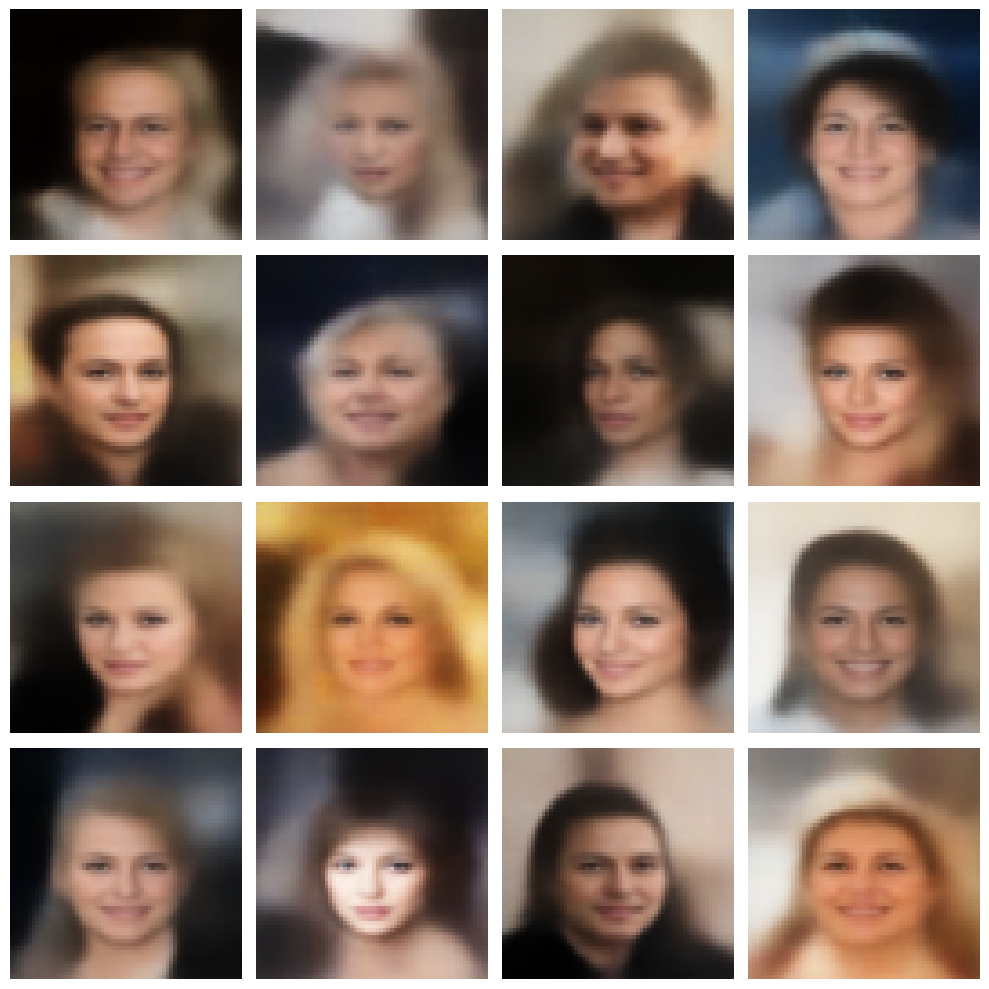

In [19]:
def plot_generated_images(vae, n=5):
    # Sample random vectors from a normal distribution
    random_latent_vectors = tf.random.normal(shape=(n * n, latent_dim))
    generated_images = vae.decoder(random_latent_vectors)
    generated_images = generated_images.numpy()

    fig, axes = plt.subplots(n, n, figsize=(10, 10))
    for i in range(n * n):
        ax = axes[i // n, i % n]
        ax.imshow(generated_images[i])
        ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_generated_images(vae, n=4)

# **no mustache -> mustache**


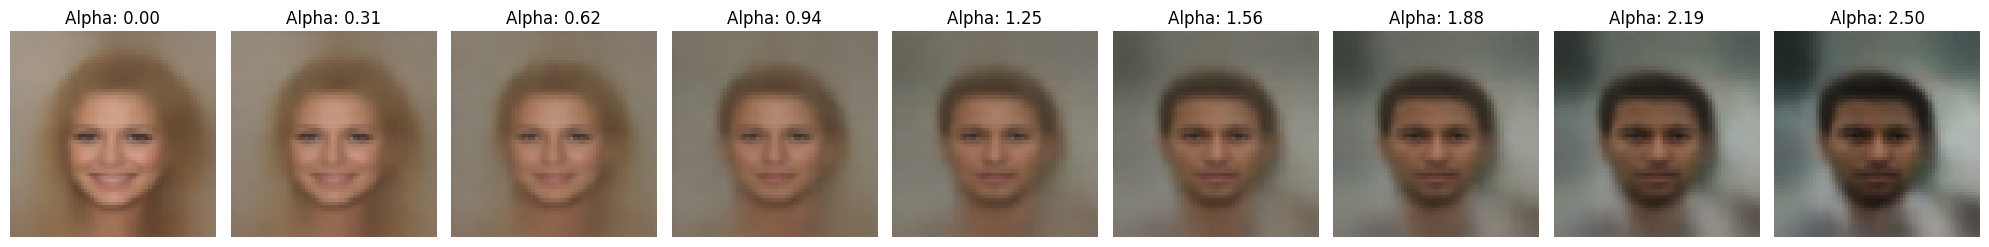

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os

# Helper function to load images
def load_images(image_ids, data_dir, image_size=(64, 64)):
    images = []
    for img_id in image_ids:
        img_path = os.path.join(data_dir, 'img_align_celeba', 'img_align_celeba', img_id)
        # adjusting path depending on extraction
        if not os.path.exists(img_path):
            img_path = os.path.join(data_dir, 'img_align_celeba', img_id)
        img = tf.io.read_file(img_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, image_size)
        images.append(img / 255.0)
    return tf.stack(images)

# Get IDs
mustache_ids = df[df['Mustache'] == 1]['image_id'].sample(10, random_state=44).tolist()
no_mustache_ids = df[df['Mustache'] == -1]['image_id'].sample(10, random_state=44).tolist()

# Load images
imgs_mustache = load_images(mustache_ids, path)
imgs_no_mustache = load_images(no_mustache_ids, path)

# Get latent vectors
z_mean_m, _, _ = vae.encoder.predict(imgs_mustache, verbose=0)
z_mean_nm, _, _ = vae.encoder.predict(imgs_no_mustache, verbose=0)

# Calculate mean vectors and the mustache direction vector
mean_z_m = np.mean(z_mean_m, axis=0)
mean_z_nm = np.mean(z_mean_nm, axis=0)
mustache_vector = mean_z_m - mean_z_nm

# Interpolation
steps = 9
# Start with a random latent vector (or the mean no-mustache vector for better results)
base_latent = mean_z_nm

# Generate interpolated vectors
alphas = np.linspace(0, 2.5, steps) # scale alpha to see noticeable effect
interpolated_z = np.vstack([base_latent + alpha * mustache_vector for alpha in alphas])

# Decode images
generated_images = vae.decoder.predict(interpolated_z, verbose=0)

# Plotting
fig, axes = plt.subplots(1, steps, figsize=(20, 4))
for i in range(steps):
    axes[i].imshow(generated_images[i])
    axes[i].axis("off")
    axes[i].set_title(f"Alpha: {alphas[i]:.2f}")
plt.tight_layout()
plt.show()


# **not bald -> bald**

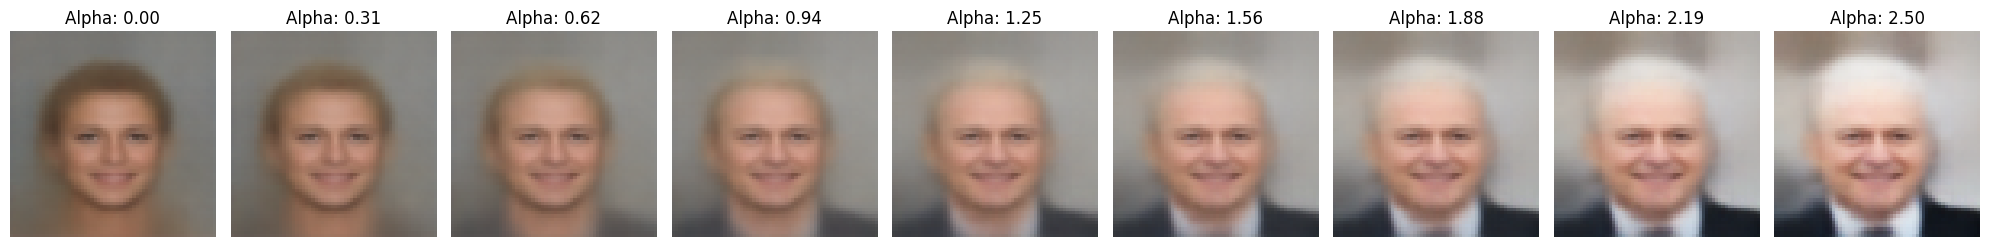

In [31]:
# Get IDs for Bald
bald_ids = df[df['Bald'] == 1]['image_id'].sample(10, random_state=41).tolist()
no_bald_ids = df[df['Bald'] == -1]['image_id'].sample(10, random_state=41).tolist()

# Load images (using the load_images helper defined previously)
imgs_bald = load_images(bald_ids, path)
imgs_no_bald = load_images(no_bald_ids, path)

# Get latent vectors
z_mean_b, _, _ = vae.encoder.predict(imgs_bald, verbose=0)
z_mean_nb, _, _ = vae.encoder.predict(imgs_no_bald, verbose=0)

# Calculate mean vectors and the bald direction vector
mean_z_b = np.mean(z_mean_b, axis=0)
mean_z_nb = np.mean(z_mean_nb, axis=0)
bald_vector = mean_z_b - mean_z_nb

# Interpolation
steps = 9
# Start with the mean no-bald vector for a clean transition
base_latent = mean_z_nb

# Generate interpolated vectors
alphas = np.linspace(0, 2.5, steps) # scale alpha to see noticeable effect
interpolated_z = np.vstack([base_latent + alpha * bald_vector for alpha in alphas])

# Decode images
generated_images = vae.decoder.predict(interpolated_z, verbose=0)

# Plotting
fig, axes = plt.subplots(1, steps, figsize=(20, 4))
for i in range(steps):
    axes[i].imshow(generated_images[i])
    axes[i].axis("off")
    axes[i].set_title(f"Alpha: {alphas[i]:.2f}")
plt.tight_layout()
plt.show()
